<a href="https://colab.research.google.com/github/vikaspr042/Ml-Lab/blob/main/1WA23CS042_LAB09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns in dataset:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


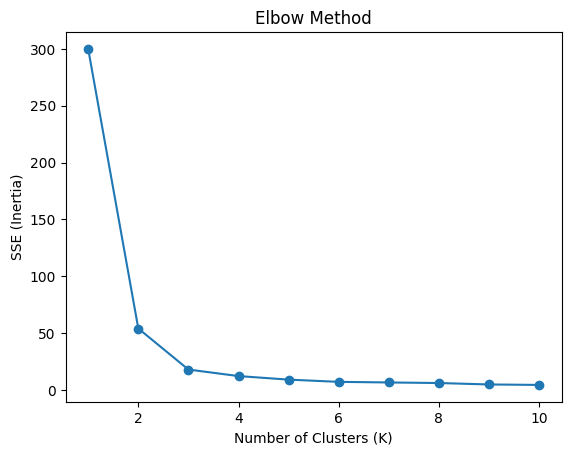


Clustered Data (first 5 rows):
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5           0.2  Iris-setosa   
4   5            5.0           3.6            1.4           0.2  Iris-setosa   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


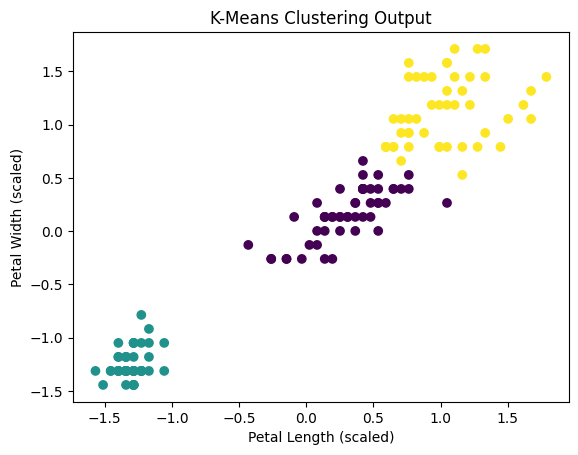


Cluster Centers (Scaled):
[[ 0.30564587  0.16609419]
 [-1.30487835 -1.25512862]
 [ 1.02813193  1.12749028]]


In [ ]:
 # Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Load dataset (put your file path here)
df = pd.read_csv("/content/Iris.csv")

# Step 3: Check columns
print("Columns in dataset:")
print(df.columns)

# Step 4: Select features (Kaggle format)
X = df[['PetalLengthCm', 'PetalWidthCm']]

# Step 5: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Elbow Method
sse = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    sse.append(km.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")
plt.show()

# Step 7: Apply K-Means (K = 3)
kmeans = KMeans(n_clusters=3, random_state=0)
y_pred = kmeans.fit_predict(X_scaled)

# Step 8: Add cluster column
df['Cluster'] = y_pred

print("\nClustered Data (first 5 rows):")
print(df.head())

# Step 9: Plot clusters
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred)
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering Output")
plt.show()

# Step 10: Print centroids
print("\nCluster Centers (Scaled):")
print(kmeans.cluster_centers_)